In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split
data = pd.read_csv("/content/Global_Pollution_Analysis.csv")

In [62]:
data.isnull().sum()

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


In [63]:
# sir no null values ie no missing values

In [64]:
data.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [65]:
from sklearn.preprocessing import MinMaxScaler
data_scaler = MinMaxScaler()
data[['CO2_Emissions (in MT)','Industrial_Waste (in tons)']] = data_scaler.fit_transform(data[['CO2_Emissions (in MT)','Industrial_Waste (in tons)']])

In [66]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['Country'] = le.fit_transform(data['Country'])
data['Year'] = le.fit_transform(data['Year'])

In [67]:
data["Yearly_Pollution"] = data["CO2_Emissions (in MT)"] + data["Industrial_Waste (in tons)"] + data["Air_Pollution_Index"] + data["Water_Pollution_Index"] +data["Soil_Pollution_Index"] +data["Plastic_Waste_Produced (in tons)"]

In [68]:
data[["Yearly_Pollution"]] = data_scaler.fit_transform(data[["Yearly_Pollution"]])

In [69]:
data.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Yearly_Pollution
0,77,5,272.70,124.27,51.95,0.949995,158.14,0.070756,41.11,37078.88,12.56,42.22,20972.96,0.741682
1,147,1,86.72,60.34,117.22,0.559811,498.04,0.092527,36.44,33128.20,5.23,137.25,34850.41,0.658207
2,136,16,91.59,83.36,121.72,0.559529,489.51,1.000000,9.38,18803.46,13.15,124.47,57773.15,0.369746
3,38,18,280.61,67.16,93.58,0.748028,145.18,0.146326,18.97,9182.27,0.78,67.80,21837.51,0.178457
4,46,8,179.16,127.53,121.55,0.768261,40.38,0.272347,34.00,39235.12,12.84,186.52,41379.37,0.784787


In [70]:
data[["Air_Pollution_Index"]] = data_scaler.fit_transform(data[["Air_Pollution_Index"]])
data[["Water_Pollution_Index"]] = data_scaler.fit_transform(data[["Water_Pollution_Index"]])
data[["Soil_Pollution_Index"]] = data_scaler.fit_transform(data[["Soil_Pollution_Index"]])

In [71]:
data["Pollution_Severity"] = pd.qcut(
    data["Yearly_Pollution"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [72]:
data.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Yearly_Pollution,Pollution_Severity
0,77,5,0.898042,0.553778,0.295481,0.949995,158.14,0.070756,41.11,37078.88,12.56,42.22,20972.96,0.741682,High
1,147,1,0.147062,0.173673,0.768178,0.559811,498.04,0.092527,36.44,33128.20,5.23,137.25,34850.41,0.658207,Medium
2,136,16,0.166727,0.310542,0.800768,0.559529,489.51,1.000000,9.38,18803.46,13.15,124.47,57773.15,0.369746,Medium
3,38,18,0.929982,0.214222,0.596973,0.748028,145.18,0.146326,18.97,9182.27,0.78,67.80,21837.51,0.178457,Low
4,46,8,0.520331,0.573161,0.799537,0.768261,40.38,0.272347,34.00,39235.12,12.84,186.52,41379.37,0.784787,High


In [73]:
x = data.drop(columns=["Pollution_Severity","Yearly_Pollution"],axis=1)
y = data["Pollution_Severity"]

In [74]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(x_train,y_train)
nb_pred = nb.predict(x_test)

In [75]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Naive bayes Multinomial Classifer predicted this data:")
print("Accuarcy:",accuracy_score(y_test,nb_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,nb_pred))
print("Classification Report:\n",classification_report(y_test,nb_pred))

Naive bayes Multinomial Classifer predicted this data:
Accuarcy: 0.6
Confusion Matrix:
 [[ 9  0  5]
 [ 2 10  1]
 [ 6  2  5]]
Classification Report:
               precision    recall  f1-score   support

        High       0.53      0.64      0.58        14
         Low       0.83      0.77      0.80        13
      Medium       0.45      0.38      0.42        13

    accuracy                           0.60        40
   macro avg       0.61      0.60      0.60        40
weighted avg       0.60      0.60      0.60        40



In [76]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
params = {
    "n_neighbors": range(1, 31),
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}
grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(x_train_scaled, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
knn = KNeighborsClassifier(n_neighbors=28,p=1,weights="uniform")
knn.fit(x_train,y_train)
knn_pred = knn.predict(x_test)
print("This is the prediction of KNN Classifier:")
print("Accuarcy:",accuracy_score(y_test,knn_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,knn_pred))
print("Classification Report:\n",classification_report(y_test,knn_pred))

Best Parameters: {'n_neighbors': 28, 'p': 1, 'weights': 'uniform'}
Best CV Accuracy: 0.8375
This is the prediction of KNN Classifier:
Accuarcy: 0.875
Confusion Matrix:
 [[13  0  1]
 [ 0 13  0]
 [ 4  0  9]]
Classification Report:
               precision    recall  f1-score   support

        High       0.76      0.93      0.84        14
         Low       1.00      1.00      1.00        13
      Medium       0.90      0.69      0.78        13

    accuracy                           0.88        40
   macro avg       0.89      0.87      0.87        40
weighted avg       0.89      0.88      0.87        40



In [77]:
from sklearn.tree import DecisionTreeClassifier
params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt", "log2"]
}
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(x_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score: 1.0


In [78]:
dt = DecisionTreeClassifier(max_depth=None,criterion='gini',min_samples_split=2,min_samples_leaf=1)
dt.fit(x_train,y_train)
dt_pred = dt.predict(x_test)
print("This is the prediction of Decision Tree Classifier:")
print("Accuarcy:",accuracy_score(y_test,dt_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,dt_pred))
print("Classification Report:",classification_report(y_test,dt_pred))

This is the prediction of Decision Tree Classifier:
Accuarcy: 0.975
Confusion Matrix:
 [[14  0  0]
 [ 0 13  0]
 [ 1  0 12]]
Classification Report:               precision    recall  f1-score   support

        High       0.93      1.00      0.97        14
         Low       1.00      1.00      1.00        13
      Medium       1.00      0.92      0.96        13

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.98        40
weighted avg       0.98      0.97      0.97        40



In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [80]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "KNN", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred)
    ]
})
print(results)

           Model  Accuracy
0    Naive Bayes     0.600
1            KNN     0.875
2  Decision Tree     0.975


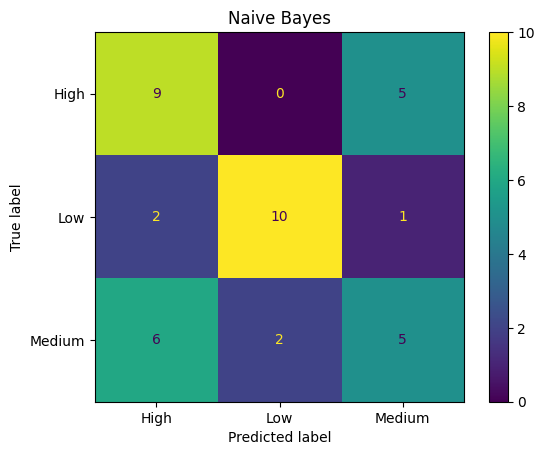

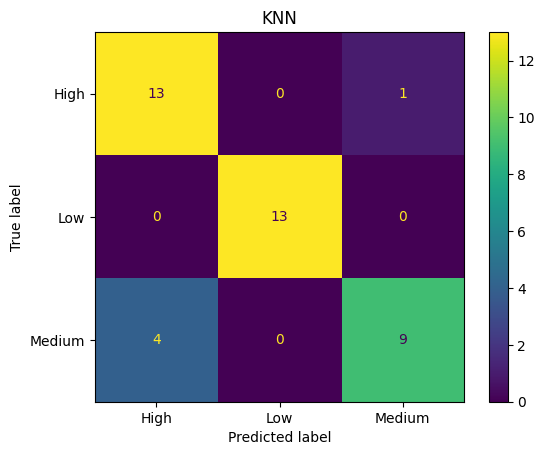

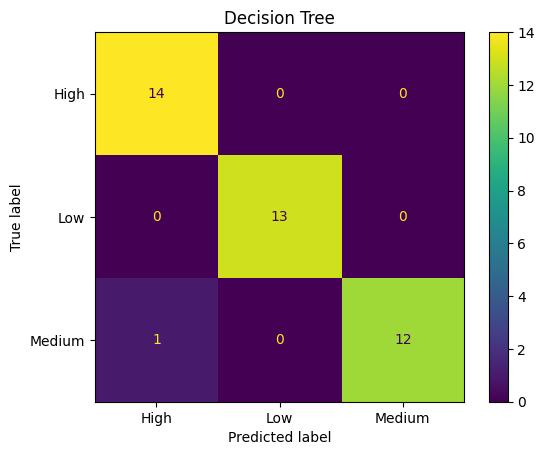

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
models = {
    "Naive Bayes": nb_pred,
    "KNN": knn_pred,
    "Decision Tree": dt_pred
}
for name, pred in models.items():
    ConfusionMatrixDisplay.from_predictions(y_test, pred)
    plt.title(name)
    plt.show()